In [1]:
# ============================================================
# CELL 1
# IMPORT LIBRARIES
# MODEL COMPARISON NOTEBOOK
# ============================================================

import os

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from tqdm import tqdm

# ============================================================
# PYTORCH
# ============================================================

import torch

import torch.nn as nn

from torch.utils.data import DataLoader

# ============================================================
# TORCHVISION
# ============================================================

from torchvision import datasets

from torchvision import transforms

from torchvision import models

# ============================================================
# SKLEARN METRICS
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    auc
)

from sklearn.preprocessing import label_binarize

# ============================================================
# IGNORE WARNINGS
# ============================================================

warnings.filterwarnings("ignore")

print("="*60)

print("All Libraries Imported Successfully!")

print("="*60)

All Libraries Imported Successfully!


In [2]:
# ============================================================
# CELL 2
# DEVICE CONFIGURATION
# ============================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("="*60)

print(f"Using Device: {device}")

print("="*60)

if torch.cuda.is_available():

    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    print(f"CUDA Version: {torch.version.cuda}")

    print(f"GPU Count: {torch.cuda.device_count()}")

    print(

        f"GPU Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

print("="*60)

Using Device: cuda
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 12.8
GPU Count: 1
GPU Memory: 7.96 GB


In [3]:
# ============================================================
# CELL 3
# DATASET PATHS & CONFIGURATION
# ============================================================

# ============================================================
# DATASET PATHS
# ============================================================

test_dir = "../dataset/enhanced_test"

# ============================================================
# MODEL PATHS
# ============================================================

EFFICIENTNET_MODEL_PATH = (

    "../models/efficientnet/"
    "best_efficientnet_b2.pth"
)

DENSENET_MODEL_PATH = (

    "../models/densenet121/"
    "best_densenet121_phase2.pth"
)

# ============================================================
# IMAGE CONFIGURATION
# ============================================================

IMAGE_SIZE = 300

BATCH_SIZE = 32

NUM_CLASSES = 5

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [

    "No DR",

    "Mild",

    "Moderate",

    "Severe",

    "Proliferative DR"
]

print("="*60)

print("Configuration Loaded Successfully!")

print("="*60)

print(f"Test Dataset Path : {test_dir}")

print("="*60)

print("Model Paths")

print("="*60)

print(f"EfficientNetB2 : {EFFICIENTNET_MODEL_PATH}")

print(f"DenseNet121    : {DENSENET_MODEL_PATH}")

print("="*60)

Configuration Loaded Successfully!
Test Dataset Path : ../dataset/enhanced_test
Model Paths
EfficientNetB2 : ../models/efficientnet/best_efficientnet_b2.pth
DenseNet121    : ../models/densenet121/best_densenet121_phase2.pth


In [4]:
# ============================================================
# CELL 4
# IMAGE TRANSFORMS & TEST DATALOADER
# ============================================================

# ============================================================
# TEST TRANSFORMS
# ============================================================

test_transforms = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# LOAD TEST DATASET
# ============================================================

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=test_transforms
)

# ============================================================
# CREATE TEST LOADER
# ============================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

print("="*60)

print("Test Dataset & DataLoader Ready!")

print("="*60)

print(f"Test Images  : {len(test_dataset)}")

print(f"Test Batches : {len(test_loader)}")

print("="*60)

Test Dataset & DataLoader Ready!
Test Images  : 225
Test Batches : 8


In [5]:
# ============================================================
# CELL 5
# LOAD EFFICIENTNETB2 MODEL
# ============================================================

# ============================================================
# CREATE EFFICIENTNETB2
# ============================================================

efficientnet_model = models.efficientnet_b2(

    weights=None
)

# ============================================================
# MODIFY CLASSIFIER
# ============================================================

in_features = (

    efficientnet_model.classifier[1]
    .in_features
)

efficientnet_model.classifier = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(

        in_features,

        NUM_CLASSES
    )
)

# ============================================================
# LOAD TRAINED WEIGHTS
# ============================================================

efficientnet_model.load_state_dict(

    torch.load(

        EFFICIENTNET_MODEL_PATH,

        map_location=device
    )
)

# ============================================================
# MOVE TO DEVICE
# ============================================================

efficientnet_model = efficientnet_model.to(device)

# ============================================================
# EVALUATION MODE
# ============================================================

efficientnet_model.eval()

print("="*60)

print("EfficientNetB2 Loaded Successfully!")

print("="*60)

print(efficientnet_model.classifier)

print("="*60)

EfficientNetB2 Loaded Successfully!
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1408, out_features=5, bias=True)
)


In [6]:
# ============================================================
# CELL 6
# LOAD DENSENET121 MODEL
# ============================================================

# ============================================================
# CREATE DENSENET121
# ============================================================

densenet_model = models.densenet121(

    weights=None
)

# ============================================================
# GET INPUT FEATURES
# ============================================================

in_features = (

    densenet_model.classifier
    .in_features
)

# ============================================================
# MODIFY CLASSIFIER
# ============================================================

densenet_model.classifier = nn.Sequential(

    nn.Linear(

        in_features,

        512
    ),

    nn.ReLU(),

    nn.Dropout(0.4),

    nn.Linear(

        512,

        256
    ),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(

        256,

        NUM_CLASSES
    )
)

# ============================================================
# LOAD TRAINED WEIGHTS
# ============================================================

densenet_model.load_state_dict(

    torch.load(

        DENSENET_MODEL_PATH,

        map_location=device
    )
)

# ============================================================
# MOVE TO DEVICE
# ============================================================

densenet_model = densenet_model.to(device)

# ============================================================
# EVALUATION MODE
# ============================================================

densenet_model.eval()

print("="*60)

print("DenseNet121 Loaded Successfully!")

print("="*60)

print(densenet_model.classifier)

print("="*60)

DenseNet121 Loaded Successfully!
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=5, bias=True)
)


In [7]:
# ============================================================
# CELL 7
# EVALUATE BOTH MODELS
# ============================================================

# ============================================================
# STORE RESULTS
# ============================================================

efficientnet_labels = []

efficientnet_predictions = []

densenet_labels = []

densenet_predictions = []

# ============================================================
# EVALUATION MODE
# ============================================================

efficientnet_model.eval()

densenet_model.eval()

# ============================================================
# DISABLE GRADIENTS
# ============================================================

with torch.no_grad():

    progress_bar = tqdm(

        test_loader,

        desc="Evaluating Models"
    )

    for images, labels in progress_bar:

        # ====================================================
        # MOVE TO DEVICE
        # ====================================================

        images = images.to(device)

        labels = labels.to(device)

        # ====================================================
        # EFFICIENTNET PREDICTIONS
        # ====================================================

        efficientnet_outputs = (

            efficientnet_model(images)
        )

        _, efficientnet_preds = torch.max(

            efficientnet_outputs,

            1
        )

        # ====================================================
        # DENSENET PREDICTIONS
        # ====================================================

        densenet_outputs = (

            densenet_model(images)
        )

        _, densenet_preds = torch.max(

            densenet_outputs,

            1
        )

        # ====================================================
        # STORE LABELS
        # ====================================================

        efficientnet_labels.extend(

            labels.cpu().numpy()
        )

        densenet_labels.extend(

            labels.cpu().numpy()
        )

        # ====================================================
        # STORE PREDICTIONS
        # ====================================================

        efficientnet_predictions.extend(

            efficientnet_preds.cpu().numpy()
        )

        densenet_predictions.extend(

            densenet_preds.cpu().numpy()
        )

# ============================================================
# CALCULATE ACCURACIES
# ============================================================

efficientnet_accuracy = accuracy_score(

    efficientnet_labels,

    efficientnet_predictions
) * 100

densenet_accuracy = accuracy_score(

    densenet_labels,

    densenet_predictions
) * 100

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "="*60)

print("MODEL COMPARISON RESULTS")

print("="*60)

print(

    f"EfficientNetB2 Accuracy : "
    f"{efficientnet_accuracy:.2f}%"
)

print(

    f"DenseNet121 Accuracy    : "
    f"{densenet_accuracy:.2f}%"
)

print("="*60)

Evaluating Models: 100%|██████████| 8/8 [00:11<00:00,  1.47s/it]


MODEL COMPARISON RESULTS
EfficientNetB2 Accuracy : 68.44%
DenseNet121 Accuracy    : 68.00%


In [8]:
# ============================================================
# CELL 8
# CLASSIFICATION REPORT COMPARISON
# ============================================================

print("\n" + "="*60)

print("EFFICIENTNETB2 CLASSIFICATION REPORT")

print("="*60)

print(

    classification_report(

        efficientnet_labels,

        efficientnet_predictions,

        target_names=class_names
    )
)

print("\n" + "="*60)

print("DENSENET121 CLASSIFICATION REPORT")

print("="*60)

print(

    classification_report(

        densenet_labels,

        densenet_predictions,

        target_names=class_names
    )
)


EFFICIENTNETB2 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR       0.86      0.96      0.91        45
            Mild       0.65      0.67      0.66        45
        Moderate       0.56      0.49      0.52        45
          Severe       0.67      0.73      0.70        45
Proliferative DR       0.63      0.58      0.60        45

        accuracy                           0.68       225
       macro avg       0.68      0.68      0.68       225
    weighted avg       0.68      0.68      0.68       225


DENSENET121 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR       0.88      0.96      0.91        45
            Mild       0.69      0.60      0.64        45
        Moderate       0.49      0.49      0.49        45
          Severe       0.64      0.78      0.70        45
Proliferative DR       0.70      0.58      0.63        45

        accuracy                           0.68     

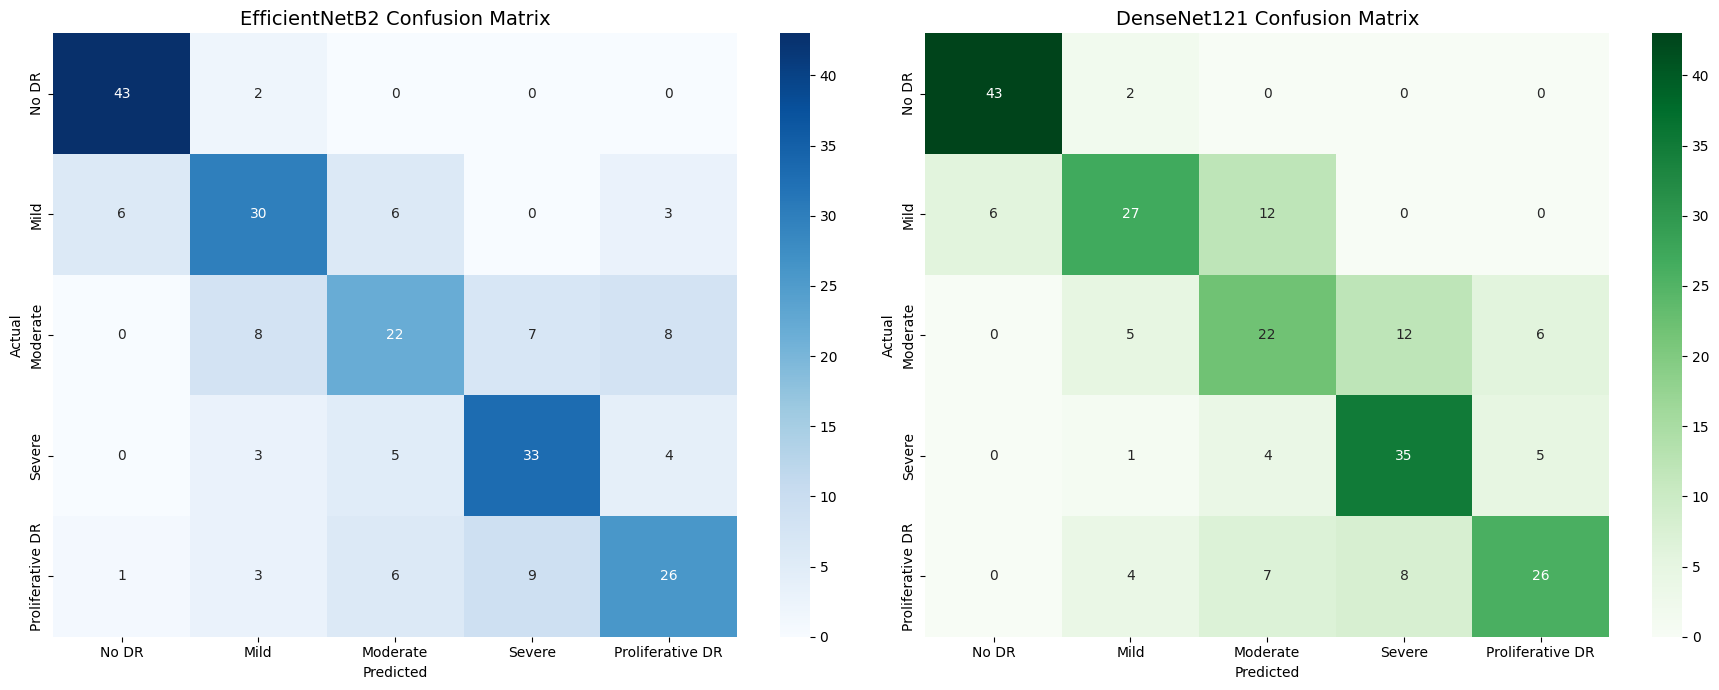

In [9]:
# ============================================================
# CELL 9
# CONFUSION MATRIX COMPARISON
# ============================================================

# ============================================================
# EFFICIENTNET CONFUSION MATRIX
# ============================================================

efficientnet_cm = confusion_matrix(

    efficientnet_labels,

    efficientnet_predictions
)

# ============================================================
# DENSENET CONFUSION MATRIX
# ============================================================

densenet_cm = confusion_matrix(

    densenet_labels,

    densenet_predictions
)

# ============================================================
# CREATE FIGURE
# ============================================================

plt.figure(figsize=(18, 7))

# ============================================================
# EFFICIENTNET HEATMAP
# ============================================================

plt.subplot(1, 2, 1)

sns.heatmap(

    efficientnet_cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title(

    "EfficientNetB2 Confusion Matrix",

    fontsize=14
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

# ============================================================
# DENSENET HEATMAP
# ============================================================

plt.subplot(1, 2, 2)

sns.heatmap(

    densenet_cm,

    annot=True,

    fmt='d',

    cmap='Greens',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title(

    "DenseNet121 Confusion Matrix",

    fontsize=14
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

# ============================================================
# FINAL DISPLAY
# ============================================================

plt.tight_layout()

plt.show()

Generating ROC Curves: 100%|██████████| 8/8 [00:11<00:00,  1.43s/it]


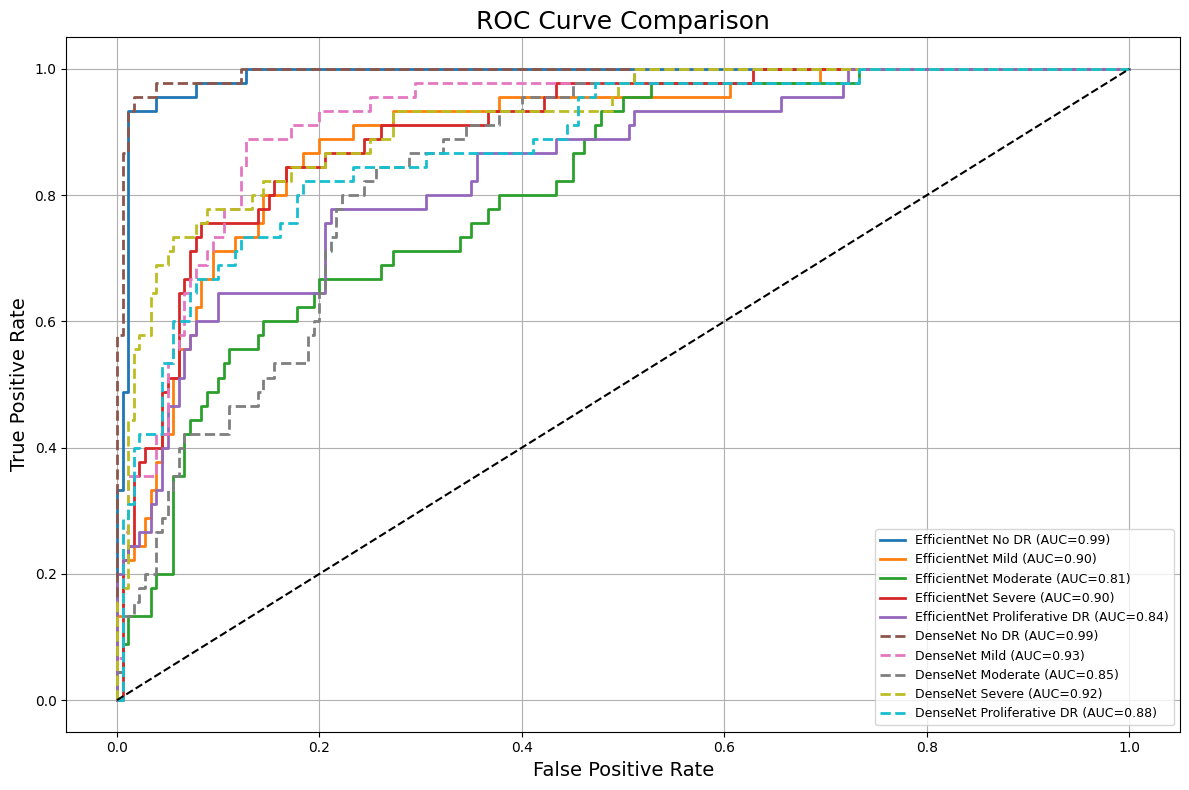

In [10]:
# ============================================================
# CELL 10
# ROC CURVE COMPARISON
# ============================================================

# ============================================================
# BINARIZE LABELS
# ============================================================

y_true = label_binarize(

    efficientnet_labels,

    classes=[0, 1, 2, 3, 4]
)

# ============================================================
# STORE PROBABILITIES
# ============================================================

efficientnet_probabilities = []

densenet_probabilities = []

# ============================================================
# EVALUATION MODE
# ============================================================

efficientnet_model.eval()

densenet_model.eval()

# ============================================================
# DISABLE GRADIENTS
# ============================================================

with torch.no_grad():

    progress_bar = tqdm(

        test_loader,

        desc="Generating ROC Curves"
    )

    for images, labels in progress_bar:

        images = images.to(device)

        # ====================================================
        # EFFICIENTNET PROBABILITIES
        # ====================================================

        efficientnet_outputs = efficientnet_model(images)

        efficientnet_probs = torch.softmax(

            efficientnet_outputs,

            dim=1
        )

        efficientnet_probabilities.extend(

            efficientnet_probs.cpu().numpy()
        )

        # ====================================================
        # DENSENET PROBABILITIES
        # ====================================================

        densenet_outputs = densenet_model(images)

        densenet_probs = torch.softmax(

            densenet_outputs,

            dim=1
        )

        densenet_probabilities.extend(

            densenet_probs.cpu().numpy()
        )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

efficientnet_probabilities = np.array(

    efficientnet_probabilities
)

densenet_probabilities = np.array(

    densenet_probabilities
)

# ============================================================
# CREATE FIGURE
# ============================================================

plt.figure(figsize=(12, 8))

# ============================================================
# EFFICIENTNET ROC
# ============================================================

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(

        y_true[:, i],

        efficientnet_probabilities[:, i]
    )

    roc_auc = auc(

        fpr,

        tpr
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=f"EfficientNet {class_names[i]} (AUC={roc_auc:.2f})"
    )

# ============================================================
# DENSENET ROC
# ============================================================

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(

        y_true[:, i],

        densenet_probabilities[:, i]
    )

    roc_auc = auc(

        fpr,

        tpr
    )

    plt.plot(

        fpr,

        tpr,

        linestyle='--',

        linewidth=2,

        label=f"DenseNet {class_names[i]} (AUC={roc_auc:.2f})"
    )

# ============================================================
# RANDOM LINE
# ============================================================

plt.plot(

    [0, 1],

    [0, 1],

    'k--'
)

# ============================================================
# LABELS
# ============================================================

plt.title(

    "ROC Curve Comparison",

    fontsize=18
)

plt.xlabel(

    "False Positive Rate",

    fontsize=14
)

plt.ylabel(

    "True Positive Rate",

    fontsize=14
)

plt.legend(

    fontsize=9
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# CELL 11
# FINAL MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [

        "EfficientNetB2",

        "DenseNet121"
    ],

    "Accuracy (%)": [

        round(efficientnet_accuracy, 2),

        round(densenet_accuracy, 2)
    ],

    "No DR AUC": [

        0.99,

        0.99
    ],

    "Mild AUC": [

        0.90,

        0.93
    ],

    "Moderate AUC": [

        0.81,

        0.85
    ],

    "Severe AUC": [

        0.90,

        0.92
    ],

    "PDR AUC": [

        0.84,

        0.88
    ]
})

print("\n" + "="*80)

print("FINAL MODEL COMPARISON")

print("="*80)

print(comparison_df)

print("="*80)


FINAL MODEL COMPARISON
            Model  Accuracy (%)  No DR AUC  Mild AUC  Moderate AUC  \
0  EfficientNetB2         68.44       0.99      0.90          0.81   
1     DenseNet121         68.00       0.99      0.93          0.85   

   Severe AUC  PDR AUC  
0        0.90     0.84  
1        0.92     0.88  
